In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from utils import load_data

sns.set_style("whitegrid")
sns.set_context("notebook")

plt.rcParams.update({
    'svg.fonttype': 'none',  # Export text as text not curves
    'font.size': 16, 
    "lines.linewidth": 2, 
    "axes.labelsize": 18,
    "axes.titlesize": 22
})

In [2]:
# Parameters
db = "mcl1_mmpbsa"
TITLE = "MCL1-MMPBSA"


In [3]:
db_batch = f"{db}_batch600.sqlite"
db = f"{db}_sequential.sqlite"
print(db, db_batch)

mcl1_mmpbsa_sequential.sqlite mcl1_mmpbsa_batch600.sqlite


In [4]:
MOLS_PER_ITER = 600

In [5]:
OUTPUT_PREFIX = db.split(".")[0]

In [6]:
data_batch, top_k_batch, source = load_data(f"results/{db_batch}", k_ratio=0.01)
data, top_k, source = load_data(f"results/{db}", k_ratio=0.01)
assert (top_k_batch == top_k).all().all()
K = len(top_k)
data_batch["Surrogate"] = (data_batch["Surrogate"] + " (B)")
data_batch["Iteration"] *= MOLS_PER_ITER
data["Scenario"] = "Sequential"
data_batch["Scenario"] = "Batched"
data_batch["experiment_id"] = data_batch["experiment_id"] + data["experiment_id"].max()  # Start all from 0
df = pd.concat([data, data_batch], ignore_index=True)

In [7]:
HUE_ORDER=sorted(df["Surrogate"].unique())
HUE_ORDER

['Linear', 'Linear (B)']

/tmp/ipykernel_1529935/207230637.py:1: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  g = sns.pointplot(


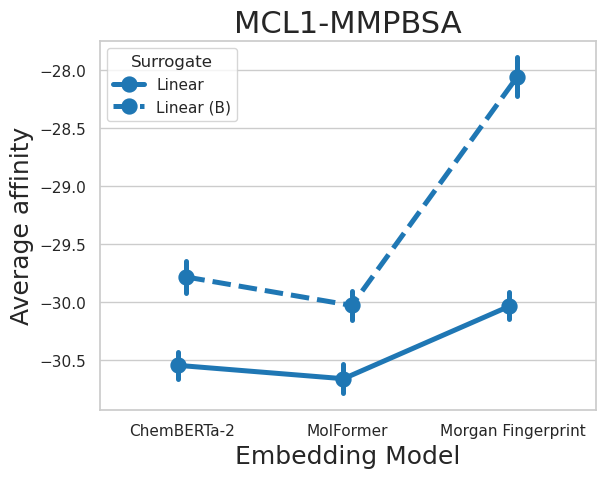

In [8]:
g = sns.pointplot(
    df,
    y="affinity",
    x="Embedding Model",
    hue="Surrogate",
    hue_order=HUE_ORDER,
    order=sorted(df["Embedding Model"].unique()),
    linestyles=["-", "--", "-", "--"],
    palette=["tab:blue", "tab:blue", "tab:orange", "tab:orange"],
    dodge=True
)
g.set_ylabel("Average affinity")
g.set_title(TITLE)
plt.savefig(f"figures/avg_affinity_{OUTPUT_PREFIX}.svg", format="svg")

In [9]:
tbl = df.groupby(["experiment_id", "Scenario", "Embedding Model", "Surrogate"])["is_top_k"].agg(lambda x: x.sum() / K)
tbl.reset_index().sort_values(by="Embedding Model")

,experiment_id,Scenario,Embedding Model,Surrogate,is_top_k
1,2,Sequential,ChemBERTa-2,Linear,0.541315
3,4,Batched,ChemBERTa-2,Linear (B),0.563238
2,3,Sequential,MolFormer,Linear,0.711636
5,6,Batched,MolFormer,Linear (B),0.600337
0,1,Sequential,Morgan Fingerprint,Linear,0.426644
4,5,Batched,Morgan Fingerprint,Linear (B),0.244519


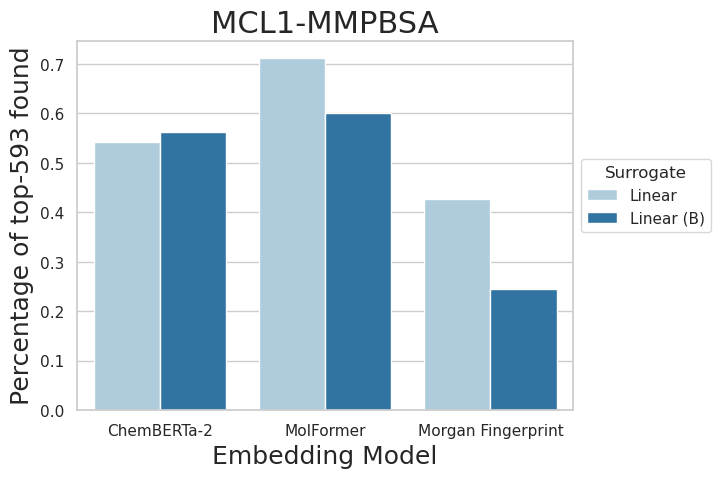

In [10]:
g = sns.barplot(
    df,
    y="is_top_k",
    x="Embedding Model",
    hue="Surrogate",
    hue_order=HUE_ORDER,
    errorbar=None,
    estimator = lambda x: x.sum() / K,
    order=sorted(df["Embedding Model"].unique()),
    dodge=True,
    palette="Paired", legend="brief"
)
g.set_ylabel(f"Percentage of top-{K} found")
g.set_title(TITLE)
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 0.7))
plt.savefig(f"figures/top_k_{OUTPUT_PREFIX}.svg", format="svg")

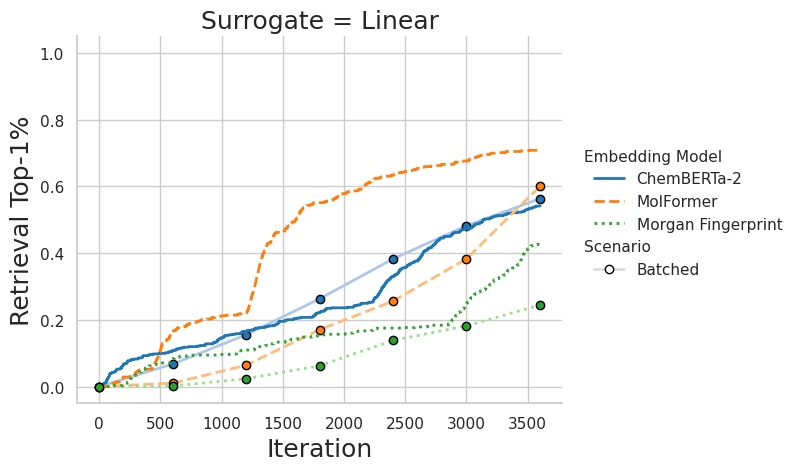

In [11]:
from utils import ProcessPlotter

df["Surrogate"] = df["Surrogate"].str.removesuffix(" (B)")
p = ProcessPlotter(df, len(top_k))
p.plot(col="Surrogate", col_order=["Linear"])

plt.savefig(f"figures/top_k_iter_{OUTPUT_PREFIX}.pdf", dpi=300, bbox_inches="tight")

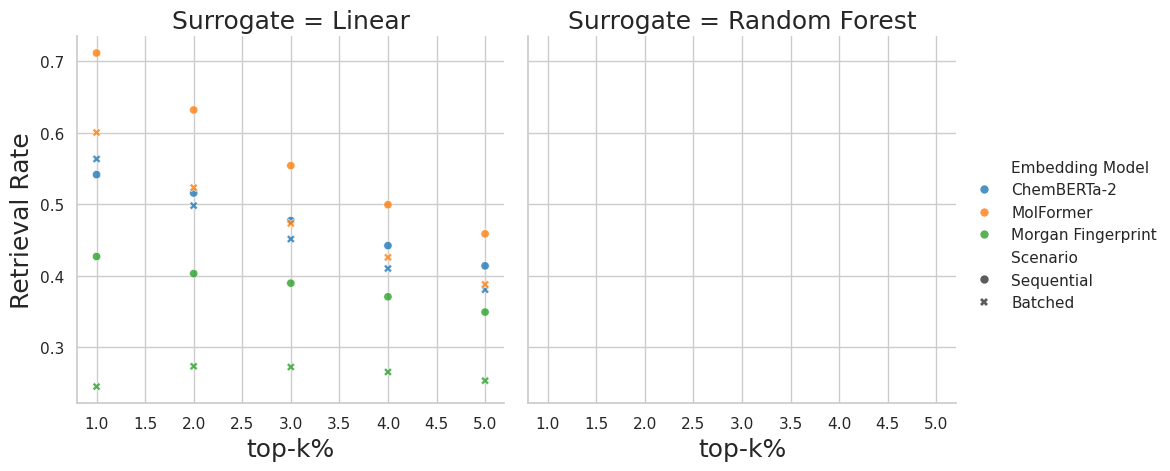

In [12]:
from math import floor
import pandas as pd

N_samples = data.groupby("experiment_id").size().unique()
assert len(N_samples) == 1
N_sampled = N_samples.item()

results = []
for ratio in range(1, 6):
    
    k = int(floor(len(source) * ratio / 100))
    top = source.sort_values(by="target")[:k]

    is_hit = df["molecule"].isin(top["smiles"])
    retrieval_rates = df[is_hit].groupby(["Embedding Model", "Surrogate", "Scenario"]).size() / k
    retrieval_rates = retrieval_rates.rename("Retrieval Rate")
    retrieval_rates = retrieval_rates.reset_index()

    retrieval_rates["top-k%"] = ratio
    retrieval_rates["num"] = k
    results.append(retrieval_rates)

retrieval_results = pd.concat(results)
sns.relplot(
    retrieval_results, x="top-k%", y="Retrieval Rate", hue="Embedding Model",
    hue_order=sorted(data["Embedding Model"].unique()),
    style="Scenario", 
    style_order=["Sequential", "Batched"],
    col="Surrogate", col_order=["Linear", "Random Forest"],
    alpha=0.8
    )